# Xenium Human Lung Cancer (FFPE) workflow in R

The same end-to-end analysis as `humnan_lung_cancer_workflow.ipynb` (Python), rebuilt with R and Bioconductor tools on the same dataset. The goal is not only to translate the code but to **cross-check every key result between two independent toolchains**, and to use the R tool where it is the stronger method.

**Dataset:** 10x Genomics Xenium v1, human lung cancer (FFPE), Human Multi-Tissue and Cancer panel (377 genes), 162,254 cells, Xenium Onboard Analysis 2.0.0.

**Environment:** conda environment `spatialR_env` (R 4.5.3, Bioconductor 3.22), Jupyter kernel **R (spatialR_env)**. Every package, its version and its purpose are listed in `spatial_transcriptomic_analysis_R_packages.md`.

**Data location:** raw and processed files live outside the repository in `~/data/xenium_lung/` (R outputs in `~/data/xenium_lung/processed/R/`).

### Proposed pipeline

Step numbers match the Python notebook, so the two can be read side by side.

| # | Step | Main R / Bioconductor tools | Cross-check against the Python result |
|---|---|---|---|
| 1 | **Download Dataset A**: verify the files on disk, download only what is missing | `download.file`, `tools::md5sum` | Same files and sizes |
| 2 | **Input data overview**: annotated folder tree and a data card of every file (headers only) | `fs`, `arrow` (Parquet schemas), `hdf5r` (matrix layout), `terra` (OME-TIFF dimensions and pyramid levels) | Same file inventory |
| 3 | **Load** the Xenium bundle into a Seurat object and **explore the raw tables** (transcripts, cells, boundaries) | **Seurat `LoadXenium()`**, `arrow`, `dplyr` | Matrix total = 9,182,510 gene transcripts |
| 4 | **Quality control**: per-cell metrics, thresholds, filtering | Seurat, `cells.parquet` (cell and nucleus area) | Same thresholds keep 154,394 cells |
| 5 | **Normalise and cluster**: normalisation, PCA, Leiden, UMAP, marker genes | Seurat, **presto** (fast Wilcoxon) | Cluster agreement (ARI) with scanpy and the 10x clustering |
| 6 | **Annotate cell types**: marker scores, subclustering of T/NK and myeloid cells, reference-based labels | `AddModuleScore`, **SingleR** + **celldex** | Agreement with the Python manual annotation |
| 7 | **Spatial analysis**: neighbourhood enrichment, tissue domains / niches, immune infiltration, TLS-like aggregates | **imcRtools**, **Banksy**, `RANN`, `dbscan` | Same co-localisation and exclusion patterns |
| 8 | **Align the H&E image** with the 10x affine matrix and overlay cell types | `terra`, alignment matrix | Same alignment QC (hematoxylin vs DAPI) |
| 9 | **TIME deep-dive**: checkpoint expression, CD8 T-cell states by location, spatial ligand-receptor contacts, immune phenotypes (inflamed / excluded / desert), immunosuppressive balance | `dplyr`, permutation tests, **CellChat v2** (spatial mode) | Same TIME findings |
| 10 | **Spatial statistics**: Moran's I, co-occurrence, Ripley's L, network centrality, ligand-receptor analysis | **Voyager**, **spatstat**, `igraph` | Same patterns; spatstat uses the real tissue outline instead of a convex hull |

**Where R adds something the Python notebook does not:** reference-based annotation with SingleR (Step 6), a dedicated spatial-domain method, Banksy (Step 7), spatially constrained cell-cell communication with CellChat (Step 9), and Ripley's statistics with a true tissue window in spatstat (Step 10).

**Where R is weaker:** handling very large pyramidal microscopy images (Step 8). That step is kept light and says so.

## Setup

Libraries, data locations and two plotting helpers used throughout. The cell stops with a clear message if the notebook is not running in the **R (spatialR_env)** kernel. Paths are printed relative to the home folder, never in full.

In [5]:
# This notebook needs the spatialR_env kernel
if (!grepl("spatialR_env", R.home())) stop("Wrong kernel. Use Kernel > Change Kernel > 'R (spatialR_env)'.")

suppressPackageStartupMessages({
  library(Seurat)
  library(arrow)
  library(dplyr)
  library(ggplot2)
  library(patchwork)
  library(hdf5r)
})
options(repr.plot.width = 14, repr.plot.height = 5, warn = 1)

DATA_ROOT <- path.expand("~/data/xenium_lung")
SAMPLE <- "Xenium_V1_humanLung_Cancer_FFPE"
SAMPLE_DIR <- file.path(DATA_ROOT, SAMPLE)
OUTS_DIR <- file.path(SAMPLE_DIR, "outs")
R_DIR <- file.path(DATA_ROOT, "processed", "R")          # R outputs, outside OneDrive
dir.create(R_DIR, recursive = TRUE, showWarnings = FALSE)
show_path <- function(p) sub(path.expand("~"), "~", p, fixed = TRUE)   # never print full paths

# Tissue map in true micron coordinates (Seurat's Image*Plot functions swap x / y by default,
# which shows this wide section in portrait); y is reversed to match the image orientation
tissue_plot <- function(obj, colour_by, title, size = 0.15) {
  xy <- GetTissueCoordinates(obj, image = "fov")
  d <- data.frame(x = xy$x / 1000, y = xy$y / 1000, value = FetchData(obj, colour_by)[xy$cell, 1])
  p <- ggplot(d, aes(x, y, colour = value)) + geom_point(size = size, stroke = 0) + coord_equal() +
    scale_y_reverse() + labs(title = title, x = "x (mm)", y = "y (mm)", colour = NULL) + theme_classic(base_size = 10)
  p
}

# One small panel per cluster: that cluster in colour over all other cells in grey
cluster_panels <- function(obj, cluster_col, ncol = 2) {
  xy <- GetTissueCoordinates(obj, image = "fov")
  d <- data.frame(x = xy$x / 1000, y = xy$y / 1000, cluster = FetchData(obj, cluster_col)[xy$cell, 1])
  n <- table(d$cluster)
  d$panel <- factor(sprintf("cluster %s  (%s cells, %.1f%%)", d$cluster, trimws(format(n[as.character(d$cluster)], big.mark = ",")),
                            100 * n[as.character(d$cluster)] / nrow(d)), levels = unique(sprintf(
                    "cluster %s  (%s cells, %.1f%%)", names(n), trimws(format(n, big.mark = ",")), 100 * n / nrow(d))))
  ggplot(d, aes(x, y)) +
    geom_point(data = d[, c("x", "y")], colour = "#e3e6ea", size = 0.02, stroke = 0) +
    geom_point(aes(colour = cluster), size = 0.12, stroke = 0, show.legend = FALSE) +
    facet_wrap(~panel, ncol = ncol) + coord_equal() + scale_y_reverse() + theme_void(base_size = 9) +
    theme(strip.text = element_text(hjust = 0, margin = margin(2, 0, 2, 0)))
}

cat("R", paste(R.version$major, R.version$minor, sep = "."), "| Seurat", as.character(packageVersion("Seurat")),
    "| outputs ->", show_path(R_DIR), "\n")

R 4.5.3 | Seurat 5.5.1 | outputs -> ~/data/xenium_lung/processed/R 


## Step 1: Download Dataset A

The data were downloaded once, by the Python workflow, to `~/data/xenium_lung/`. By default this step therefore makes **no network connection**: it only confirms that the five files are on disk and reports their sizes.

Set `DOWNLOAD_DATA <- TRUE` to run the full download path instead (for a fresh machine): each file's size on disk is compared with the 10x server, only missing or incomplete files are downloaded, and `curl` resumes a partial file from where it stopped. The output bundle is unzipped only if `outs/` does not exist yet.

**Cross-check:** same five files, same sizes as the Python Step 1.

In [6]:
DOWNLOAD_DATA <- FALSE   # TRUE = check the 10x server and download missing or incomplete files

BASE_URL <- paste0("https://cf.10xgenomics.com/samples/xenium/2.0.0/", SAMPLE)
FILES <- paste0(SAMPLE, c("_metrics_summary.csv", "_gene_panel.json", "_he_imagealignment.csv",
                          "_outs.zip", "_he_image.ome.tif"))

if (DOWNLOAD_DATA) {
  dir.create(SAMPLE_DIR, recursive = TRUE, showWarnings = FALSE)
  remote_size <- function(url) {
    h <- curl::curl_fetch_memory(url, handle = curl::new_handle(nobody = TRUE, accept_encoding = "identity"))
    as.numeric(curl::parse_headers_list(h$headers)[["content-length"]])
  }
  status <- do.call(rbind, lapply(FILES, function(f) {
    local <- file.path(SAMPLE_DIR, f)
    size_remote <- remote_size(file.path(BASE_URL, f))
    size_local <- if (file.exists(local)) file.size(local) else 0
    action <- if (size_local == size_remote) "present, complete" else {
      # curl resumes a partial file from where it stopped
      curl::curl_download(file.path(BASE_URL, f), local, mode = "ab",
                          handle = curl::new_handle(resume_from = size_local, accept_encoding = "identity"))
      if (file.size(local) == size_remote) "downloaded" else "INCOMPLETE: re-run this cell"
    }
    data.frame(file = f, size_GB = round(size_remote / 1e9, 3), status = action)
  }))
  if (!file.exists(file.path(OUTS_DIR, "experiment.xenium")))
    unzip(file.path(SAMPLE_DIR, paste0(SAMPLE, "_outs.zip")), exdir = OUTS_DIR)
} else {
  # Offline check: files must already be on disk
  present <- file.exists(file.path(SAMPLE_DIR, FILES))
  status <- data.frame(file = FILES,
                       size_GB = ifelse(present, round(file.size(file.path(SAMPLE_DIR, FILES)) / 1e9, 3), NA),
                       status = ifelse(present, "present (download skipped)", "MISSING: set DOWNLOAD_DATA <- TRUE"))
}
status
cat("outs/ extracted:", file.exists(file.path(OUTS_DIR, "experiment.xenium")), "\n")

file,size_GB,status
<chr>,<dbl>,<chr>
Xenium_V1_humanLung_Cancer_FFPE_metrics_summary.csv,0.000,present (download skipped)
Xenium_V1_humanLung_Cancer_FFPE_gene_panel.json,0.000,present (download skipped)
Xenium_V1_humanLung_Cancer_FFPE_he_imagealignment.csv,0.000,present (download skipped)
Xenium_V1_humanLung_Cancer_FFPE_outs.zip,7.988,present (download skipped)
Xenium_V1_humanLung_Cancer_FFPE_he_image.ome.tif,1.191,present (download skipped)


outs/ extracted: TRUE 


## Step 2: Input data overview

Get to know the input before analysing it. Nothing large is loaded: only file listings and file headers are read.

### 2a. Annotated folder tree

| Role | Meaning |
|---|---|
| `CORE` | Primary inputs (transcripts, cells, boundaries, count matrix) |
| `IMAGE` | Microscopy images |
| `META` / `QC` | Run metadata and quality reports |
| `BASELINE` | 10x's own clustering, to benchmark against |
| `EXPLORER` | Xenium Explorer viewer formats |
| `COPY` | Same content as a `CORE` file in another format |
| `ARCHIVE` | Compressed download bundle |

In [7]:
# Step 2a: annotated folder tree with sizes, role tags and plain-language descriptions
P <- paste0(SAMPLE, "_")
FILE_INFO <- list(   # path relative to the sample folder -> c(role, description)
  setNames(list(c("ARCHIVE", "Original 10x download of outs/. Safe to delete once unzipped")), paste0(P, "outs.zip")),
  setNames(list(c("IMAGE", "H&E stain of the same section (RGB, pyramidal)")), paste0(P, "he_image.ome.tif")),
  setNames(list(c("META", "3x3 affine matrix: H&E pixels -> Xenium morphology pixels")), paste0(P, "he_imagealignment.csv")),
  setNames(list(c("META", "Panel definition (copy of outs/gene_panel.json)")), paste0(P, "gene_panel.json")),
  setNames(list(c("QC", "Run QC numbers (copy of outs/metrics_summary.csv)")), paste0(P, "metrics_summary.csv")),
  list("outs" = c("", "Xenium Onboard Analysis 2.0 output bundle"),
       "outs/experiment.xenium" = c("META", "Run manifest (JSON): panel, pixel size, file pointers"),
       "outs/gene_panel.json" = c("META", "Panel: 377 genes + negative controls, probe and codeword details"),
       "outs/metrics_summary.csv" = c("QC", "One-row QC table: cells, transcripts, Q20 rate, control rate"),
       "outs/analysis_summary.html" = c("QC", "10x web report (QC plots + clustering)"),
       "outs/transcripts.parquet" = c("CORE", "Every decoded transcript: gene, x/y/z (um), quality qv, cell_id"),
       "outs/transcripts.csv.gz" = c("COPY", "Same as transcripts.parquet, as CSV"),
       "outs/transcripts.zarr.zip" = c("EXPLORER", "Transcripts for the Xenium Explorer viewer"),
       "outs/cells.parquet" = c("CORE", "One row per cell: centroid x/y (um), cell/nucleus area, counts"),
       "outs/cells.csv.gz" = c("COPY", "Same as cells.parquet, as CSV"),
       "outs/cells.zarr.zip" = c("EXPLORER", "Cell + nucleus masks for Xenium Explorer"),
       "outs/cell_boundaries.parquet" = c("CORE", "Cell outline polygons: vertex x/y (um) per cell_id"),
       "outs/cell_boundaries.csv.gz" = c("COPY", "Same as cell_boundaries.parquet, as CSV"),
       "outs/nucleus_boundaries.parquet" = c("CORE", "Nucleus outline polygons: vertex x/y (um) per cell_id"),
       "outs/nucleus_boundaries.csv.gz" = c("COPY", "Same as nucleus_boundaries.parquet, as CSV"),
       "outs/cell_feature_matrix.h5" = c("CORE", "Cell x feature count matrix (genes + controls)"),
       "outs/cell_feature_matrix.tar.gz" = c("COPY", "Same matrix in MEX format"),
       "outs/cell_feature_matrix.zarr.zip" = c("EXPLORER", "Count matrix for Xenium Explorer"),
       "outs/morphology.ome.tif" = c("IMAGE", "3D DAPI (nuclei) z-stack, full resolution, pyramidal"),
       "outs/morphology_focus" = c("IMAGE", "2D in-focus images, one stain per file (segmentation stains)"),
       "outs/analysis.tar.gz" = c("BASELINE", "10x clustering, differential expression, PCA, UMAP, t-SNE"),
       "outs/analysis.zarr.zip" = c("EXPLORER", "10x clustering results for Xenium Explorer"),
       "outs/aux_outputs.tar.gz" = c("QC", "Technical extras: per-cycle raw images, FOV tile positions")))
FILE_INFO <- do.call(c, FILE_INFO)

human <- function(b) {
  u <- c("B", "KB", "MB", "GB"); i <- pmax(1, pmin(4, floor(log(pmax(b, 1), 1000)) + 1))
  ifelse(i == 1, sprintf("%.0f B", b), sprintf("%.1f %s", b / 1000^(i - 1), u[i]))
}
path_size <- function(p) if (dir.exists(p)) sum(file.size(list.files(p, recursive = TRUE, full.names = TRUE))) else file.size(p)

rows <- list(); role_bytes <- c()
add <- function(prefix, name, size, role = "", desc = "")
  rows[[length(rows) + 1]] <<- data.frame(path = paste0(prefix, name), size = human(size),
                                          role = ifelse(role == "", "", paste0("[", role, "]")), description = desc)
walk <- function(dir, prefix = "") {
  entries <- list.files(dir, full.names = TRUE)
  entries <- entries[order(dir.exists(entries), tolower(basename(entries)))]
  for (k in seq_along(entries)) {
    e <- entries[k]; last <- k == length(entries)
    rel <- sub(paste0(SAMPLE_DIR, "/"), "", e, fixed = TRUE)
    info <- if (!is.null(FILE_INFO[[rel]])) FILE_INFO[[rel]] else c("", "")
    if (!dir.exists(e) && info[1] != "") role_bytes[info[1]] <<- sum(role_bytes[info[1]], file.size(e), na.rm = TRUE)
    add(prefix, paste0(if (last) "└── " else "├── ", basename(e), if (dir.exists(e)) "/" else ""), path_size(e), info[1], info[2])
    if (dir.exists(e)) walk(e, paste0(prefix, if (last) "    " else "│   "))
  }
}
add("", paste0(SAMPLE, "/"), path_size(SAMPLE_DIR), "", "Dataset A: human lung cancer, FFPE, Xenium v1 (377 genes)")
walk(SAMPLE_DIR)
tree <- do.call(rbind, rows)
# format() pads by displayed width (sprintf pads by bytes, which misaligns the multi-byte tree characters)
cat(paste(format(tree$path), format(tree$size, justify = "right"), format(tree$role), tree$description, sep = "  "), sep = "\n")

cat("\nDisk usage by role:\n")
rb <- sort(role_bytes, decreasing = TRUE)
cat(sprintf("  %-9s %9s  %5.1f%%", names(rb), human(rb), 100 * rb / sum(rb)), sep = "\n")

Xenium_V1_humanLung_Cancer_FFPE/                            17.2 GB              Dataset A: human lung cancer, FFPE, Xenium v1 (377 genes)
├── Xenium_V1_humanLung_Cancer_FFPE_gene_panel.json        209.1 KB  [META]      Panel definition (copy of outs/gene_panel.json)
├── Xenium_V1_humanLung_Cancer_FFPE_he_image.ome.tif         1.2 GB  [IMAGE]     H&E stain of the same section (RGB, pyramidal)
├── Xenium_V1_humanLung_Cancer_FFPE_he_imagealignment.csv     126 B  [META]      3x3 affine matrix: H&E pixels -> Xenium morphology pixels
├── Xenium_V1_humanLung_Cancer_FFPE_metrics_summary.csv      1.7 KB  [QC]        Run QC numbers (copy of outs/metrics_summary.csv)
├── Xenium_V1_humanLung_Cancer_FFPE_outs.zip                 8.0 GB  [ARCHIVE]   Original 10x download of outs/. Safe to delete once unzipped
└── outs/                                                    8.0 GB              Xenium Onboard Analysis 2.0 output bundle
    ├── analysis_summary.html                               10.4 MB  

### 2b. Data card: what is inside each file

- `jsonlite` reads the run manifest; `arrow::open_dataset()` reads only Parquet **footers** (schema and row count) and fetches 3 preview rows lazily; `hdf5r` reads the count-matrix layout; `terra` (GDAL) reads the H&E image header, including its 5 pyramid levels.
- The H&E alignment matrix is decomposed into scale and rotation: the H&E was scanned rotated by ~90° and at a different pixel size.
- **R-specific limitation:** the Xenium morphology images (DAPI and stains) use JPEG 2000 compression inside TIFF, which this GDAL build cannot decode. They are handled in Step 8.

In [8]:
# Step 2b: data card, read from file headers only (nothing large is loaded)
exp <- jsonlite::fromJSON(file.path(OUTS_DIR, "experiment.xenium"))
keys <- c("run_name", "region_name", "preservation_method", "panel_name", "panel_design_id",
          "panel_num_targets_predesigned", "num_cells", "transcripts_per_cell", "pixel_size",
          "analysis_sw_version", "segmentation_stain")
cat("RUN METADATA (experiment.xenium)\n"); print(data.frame(value = unlist(exp[keys])))

cat("\nTABLES (Parquet schemas; arrow reads only the file footer)\n")
for (f in c("transcripts.parquet", "cells.parquet", "cell_boundaries.parquet", "nucleus_boundaries.parquet")) {
  ds <- arrow::open_dataset(file.path(OUTS_DIR, f))
  cat(sprintf("\n%s: %s rows\n", f, format(nrow(ds), big.mark = ",")))
  print(data.frame(column = names(ds), type = sapply(ds$schema$fields, function(x) x$type$ToString())), row.names = FALSE)
  print(ds |> head(3) |> dplyr::collect() |> as.data.frame())
}

cat("\nCOUNT MATRIX (cell_feature_matrix.h5)\n")
h <- H5File$new(file.path(OUTS_DIR, "cell_feature_matrix.h5"), mode = "r")
shape <- h[["matrix/shape"]]$read(); nnz <- h[["matrix/data"]]$dims
ftype <- h[["matrix/features/feature_type"]]$read(); h$close_all()
cat(sprintf("%s cells x %s features; %.1f%% non-zero\n", format(shape[2], big.mark = ","), shape[1], 100 * nnz / prod(shape)))
print(table(feature_type = ftype))

cat("\nH&E IMAGE (via GDAL, header only)\n")
he_info <- terra::describe(file.path(SAMPLE_DIR, paste0(SAMPLE, "_he_image.ome.tif")))
cat(grep("Size is|Overviews", he_info, value = TRUE)[1:2], sep = "\n")
px <- regmatches(he_info, regexpr('PhysicalSizeX="[0-9.]+', he_info))
cat("Pixel size:", sub('PhysicalSizeX="', "", px[1]), "um\n")

M <- matrix(scan(file.path(SAMPLE_DIR, paste0(SAMPLE, "_he_imagealignment.csv")), sep = ",", quiet = TRUE),
            nrow = 3, byrow = TRUE)
cat(sprintf("\nH&E -> Xenium alignment: scale %.4f, rotation %.1f degrees, translation (%.1f, %.1f) px\n",
            sqrt(abs(det(M[1:2, 1:2]))), atan2(M[2, 1], M[1, 1]) * 180 / pi, M[1, 3], M[2, 3]))
cat("Note: the Xenium morphology images use JPEG 2000 compression, which this GDAL build cannot decode;\n",
    "their dimensions are listed in experiment.xenium and they are handled in Step 8.\n")

RUN METADATA (experiment.xenium)
                                                                             value
run_name                                          Human Multi-Tissue Cancer (FFPE)
region_name                                                      Human_Lung_Cancer
preservation_method                                                           FFPE
panel_name                    Xenium Human Multi-Tissue and Cancer Gene Expression
panel_design_id                                                          hMulti_v1
panel_num_targets_predesigned                                                  377
num_cells                                                                   162254
transcripts_per_cell                                                            46
pixel_size                                                                  0.2125
analysis_sw_version                                   xenium-2.0.0.6-35-ga7e17149a
segmentation_stain                                    

## Step 3: Load with Seurat and explore the raw tables

`Seurat::LoadXenium()` reads the whole bundle into one Seurat object: the gene-expression assay, three control assays (negative-control probes, negative-control codewords, unassigned codewords), cell centroids and the transcript positions. Seurat applies the standard quality filter (`qv >= 20`) to transcripts on loading.

### 3a. Load the dataset

In [9]:
t0 <- Sys.time()
# suppressWarnings: Seurat renames control features (e.g. NegControlProbe_00042 -> NegControlProbe-00042),
# which is harmless; suppressMessages hides its loading notices
xen <- suppressMessages(suppressWarnings(LoadXenium(OUTS_DIR, fov = "fov", assay = "Xenium")))
cat(sprintf("Loaded in %.0f s\n\n", as.numeric(difftime(Sys.time(), t0, units = "secs"))))
xen

assay_summary <- data.frame(
  assay = Assays(xen),
  features = sapply(Assays(xen), function(a) nrow(xen[[a]])),
  total_counts = sapply(Assays(xen), function(a) sum(LayerData(xen, assay = a, layer = "counts"))),
  meaning = c("Gene expression (377-gene panel)", "Unassigned codewords (decoding errors)",
              "Negative-control codewords", "Negative-control probes (background)"))
assay_summary

Loaded in 20 s



An object of class Seurat 
541 features across 162254 samples within 4 assays 
Active assay: Xenium (377 features, 0 variable features)
 1 layer present: counts
 3 other assays present: BlankCodeword, ControlCodeword, ControlProbe
 1 spatial field of view present: fov

,assay,features,total_counts,meaning
,<chr>,<dbl>,<dbl>,<chr>
Xenium,Xenium,377,9182510,Gene expression (377-gene panel)
BlankCodeword,BlankCodeword,103,695,Unassigned codewords (decoding errors)
ControlCodeword,ControlCodeword,41,171,Negative-control codewords
ControlProbe,ControlProbe,20,393,Negative-control probes (background)


### 3b. Sanity checks against the raw files

A loader should never be trusted blindly. Three checks against `cells.parquet` and the total verified in the Python workflow, then a whole-slide map of transcripts per cell.

,passed
,<lgl>
cells == cells.parquet rows,TRUE
"gene counts == Python-verified total (9,182,510)",TRUE
per-cell counts == cells.parquet transcript_counts,TRUE


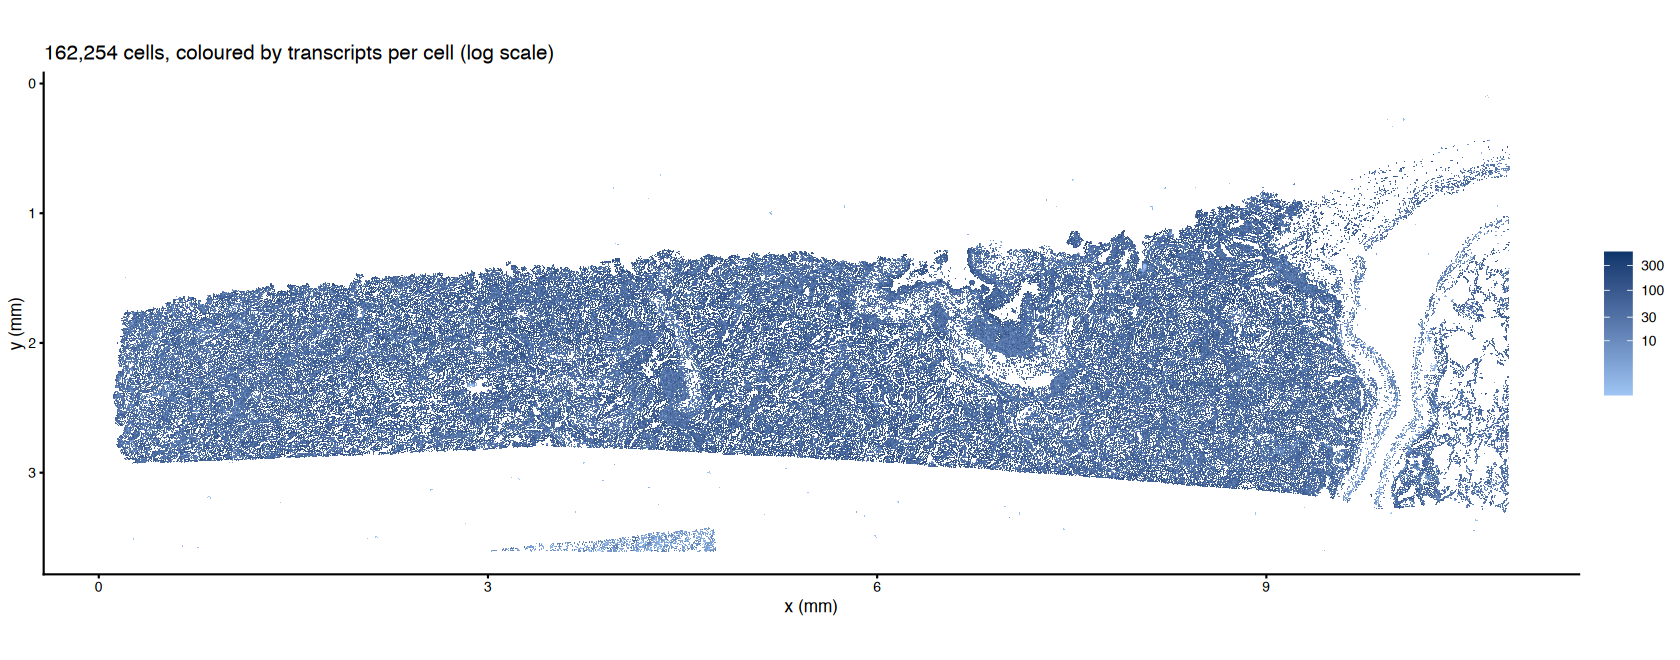

In [11]:
cells_pq <- as.data.frame(read_parquet(file.path(OUTS_DIR, "cells.parquet")))
checks <- c(
  "cells == cells.parquet rows" = ncol(xen) == nrow(cells_pq),
  "gene counts == Python-verified total (9,182,510)" = sum(xen$nCount_Xenium) == 9182510,
  "per-cell counts == cells.parquet transcript_counts" =
    all(xen$nCount_Xenium == cells_pq$transcript_counts[match(colnames(xen), cells_pq$cell_id)]))
data.frame(passed = checks)

# Whole-slide overview: every cell at its centroid, coloured by transcripts per cell
options(repr.plot.width = 14, repr.plot.height = 5.5)
xen$log_counts <- log1p(xen$nCount_Xenium)
tissue_plot(xen, "log_counts", sprintf("%s cells, coloured by transcripts per cell (log scale)", format(ncol(xen), big.mark = ","))) +
  scale_colour_gradient(low = "#9ec5f4", high = "#0d366b", breaks = log1p(c(10, 30, 100, 300)), labels = c(10, 30, 100, 300))

### 3c. Explore the raw transcripts with arrow

The same analysis as Python Step 3c, written with `arrow` + `dplyr`: which transcripts are genes vs. controls, how many pass `qv >= 20`, how many fall inside cells, and an exact reconstruction of the count-matrix total.

**Cross-check:** identical numbers to Python (12,140,711 gene transcripts; 87.4% pass Q20; 9,182,510 assigned to cells).

In [12]:
# Raw transcripts with arrow: read only the needed columns
tx <- read_parquet(file.path(OUTS_DIR, "transcripts.parquet"),
                   col_select = c("feature_name", "qv", "cell_id", "overlaps_nucleus"))
tx <- tx |> mutate(category = case_when(
  startsWith(feature_name, "NegControlProbe") ~ "Negative control probe",
  startsWith(feature_name, "NegControlCodeword") ~ "Negative control codeword",
  startsWith(feature_name, "UnassignedCodeword") ~ "Unassigned codeword",
  startsWith(feature_name, "DeprecatedCodeword") ~ "Deprecated codeword",
  TRUE ~ "Gene"))

tx |> group_by(category) |>
  summarise(transcripts = n(), frac_q20 = mean(qv >= 20), frac_in_cells = mean(cell_id != "UNASSIGNED")) |>
  arrange(desc(transcripts))

usable <- tx$category == "Gene" & tx$qv >= 20
in_cell <- tx$cell_id != "UNASSIGNED"
cat(sprintf("Gene transcripts with qv >= 20: %s; assigned to a cell: %s (%.1f%%); equals the matrix total: %s\n",
            format(sum(usable), big.mark = ","), format(sum(usable & in_cell), big.mark = ","),
            100 * mean(in_cell[usable]), sum(usable & in_cell) == sum(xen$nCount_Xenium)))
rm(tx); invisible(gc())

category,transcripts,frac_q20,frac_in_cells
<chr>,<int>,<dbl>,<dbl>
Gene,12140711,0.87354711,0.8659708
Unassigned codeword,14878,0.09087243,0.7084958
Negative control codeword,5877,0.03709376,0.7415348
Negative control probe,3555,0.14599156,0.7234880


Gene transcripts with qv >= 20: 10,605,483; assigned to a cell: 9,182,510 (86.6%); equals the matrix total: TRUE


## Step 4: Quality control

The same rules and thresholds as the Python workflow (Step 4b), so the two filtered datasets can be compared cell for cell:

| Rule | Type | Rationale |
|---|---|---|
| `nCount_Xenium >= 10` | fixed | Below ~10 transcripts a cell cannot be typed reliably on a 377-gene panel |
| `nFeature_Xenium >= 5` | fixed | At least a handful of distinct genes |
| cell area within 3 MADs (log scale) | data-driven | Removes fragments and merged cells |
| control fraction <= 5% | background | Drops cells dominated by negative-control signal |

### 4a. Per-cell QC metrics

Seurat provides counts and genes per cell; cell and nucleus area come from `cells.parquet`.

In [13]:
# Per-cell QC metrics: Seurat counts + cell / nucleus area from cells.parquet
meta <- cells_pq[match(colnames(xen), cells_pq$cell_id), ]
xen$cell_area <- meta$cell_area
xen$nucleus_area <- meta$nucleus_area
xen$nucleus_count <- if ("nucleus_count" %in% names(meta)) meta$nucleus_count else NA
xen$control_counts <- xen$nCount_ControlProbe + xen$nCount_ControlCodeword
# Control fraction = control counts / gene counts. This matches the Python workflow exactly
# (scanpy's calculate_qc_metrics sets total_counts to gene counts). Dividing by genes + controls
# instead is equally defensible but flags 6 fewer cells: small definitions change cell numbers.
xen$control_frac <- ifelse(xen$nCount_Xenium > 0, xen$control_counts / xen$nCount_Xenium, 0)

qc <- xen@meta.data[, c("nCount_Xenium", "nFeature_Xenium", "cell_area", "nucleus_area", "control_counts")]
t(sapply(qc, function(v) round(quantile(v, c(.01, .05, .25, .5, .75, .95, .99), na.rm = TRUE), 2)))

,1%,5%,25%,50%,75%,95%,99%
nCount_Xenium,3.00,10.00,27.00,46.00,75.00,140.00,202.47
nFeature_Xenium,3.00,8.00,19.00,29.00,40.00,57.00,71.00
cell_area,11.83,20.23,38.74,60.51,94.87,163.33,229.62
nucleus_area,5.69,8.35,17.39,27.77,46.51,76.95,101.65
control_counts,0.00,0.00,0.00,0.00,0.00,0.00,0.00


### 4b. Thresholds and distributions

**A cross-check that caught a definition difference.** The first R version divided control counts by *all* counts (genes + controls) and kept 154,400 cells, 6 more than Python. The Python control fraction uses gene counts as the denominator (scanpy's `calculate_qc_metrics` sets `total_counts` to gene counts). Both are defensible; matching the Python definition makes the two pipelines agree exactly. Small definitional choices change cell numbers, which is why independent re-implementation is valuable.

Cell area bounds (3 MADs, log scale): 7.7 - 435.4 um^2


,cells_flagged,pct
,<dbl>,<dbl>
low_counts,7782,4.80
low_genes,3210,1.98
small_area,316,0.19
large_area,10,0.01
high_control,42,0.03


Pass: 154,394 cells (95.2%). Python workflow kept 154,394: TRUE


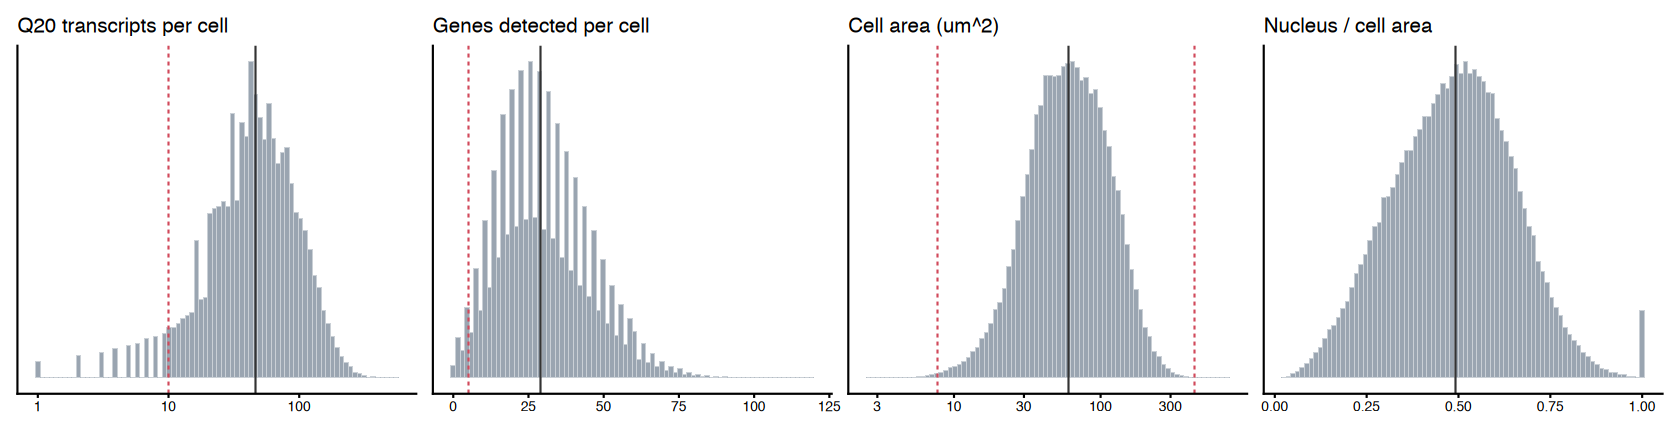

In [14]:
# Same thresholds as the Python workflow (Step 4b), so results are directly comparable
MIN_COUNTS <- 10
MIN_GENES <- 5
AREA_NMADS <- 3
MAX_CONTROL_FRAC <- 0.05

log_area <- log1p(xen$cell_area)
area_bounds <- expm1(median(log_area) + c(-1, 1) * AREA_NMADS * mad(log_area))   # mad() includes the 1.4826 factor

flags <- data.frame(
  low_counts = xen$nCount_Xenium < MIN_COUNTS,
  low_genes = xen$nFeature_Xenium < MIN_GENES,
  small_area = xen$cell_area < area_bounds[1],
  large_area = xen$cell_area > area_bounds[2],
  high_control = xen$control_frac > MAX_CONTROL_FRAC)
xen$qc_pass <- !apply(flags, 1, any)
cat(sprintf("Cell area bounds (3 MADs, log scale): %.1f - %.1f um^2\n", area_bounds[1], area_bounds[2]))
data.frame(cells_flagged = colSums(flags), pct = round(100 * colMeans(flags), 2))
cat(sprintf("Pass: %s cells (%.1f%%). Python workflow kept 154,394: %s\n",
            format(sum(xen$qc_pass), big.mark = ","), 100 * mean(xen$qc_pass), sum(xen$qc_pass) == 154394))

options(repr.plot.width = 14, repr.plot.height = 3.6)
hist_panel <- function(v, title, cuts = NULL, log_x = FALSE) {
  d <- data.frame(v = v[is.finite(v) & (!log_x | v > 0)])
  p <- ggplot(d, aes(v)) + geom_histogram(bins = 80, fill = "#9aa5b1", colour = "white", linewidth = 0.1) +
    geom_vline(xintercept = median(d$v), colour = "#333333") + labs(title = title, x = NULL, y = NULL) +
    theme_classic(base_size = 10) + theme(axis.text.y = element_blank(), axis.ticks.y = element_blank())
  if (!is.null(cuts)) p <- p + geom_vline(xintercept = cuts, colour = "#d1495b", linetype = "dashed")
  if (log_x) p <- p + scale_x_log10()
  p
}
hist_panel(xen$nCount_Xenium, "Q20 transcripts per cell", MIN_COUNTS, TRUE) +
  hist_panel(xen$nFeature_Xenium, "Genes detected per cell", MIN_GENES) +
  hist_panel(xen$cell_area, "Cell area (um^2)", area_bounds, TRUE) +
  hist_panel(xen$nucleus_area / xen$cell_area, "Nucleus / cell area") + plot_layout(nrow = 1)

### 4c. Filter and save

The filtered Seurat object is saved as `.rds` in `~/data/xenium_lung/processed/R/`, outside OneDrive.

In [15]:
xen_qc <- suppressWarnings(subset(xen, subset = qc_pass))   # "Not validating ..." notices are harmless
saveRDS(xen_qc, file.path(R_DIR, paste0(SAMPLE, "_qc_seurat.rds")))
cat(sprintf("Saved %s cells x %s genes to %s\n", format(ncol(xen_qc), big.mark = ","), nrow(xen_qc),
            show_path(file.path(R_DIR, paste0(SAMPLE, "_qc_seurat.rds")))))
rm(xen); invisible(gc())

Saved 154,394 cells x 377 genes to ~/data/xenium_lung/processed/R/Xenium_V1_humanLung_Cancer_FFPE_qc_seurat.rds


## Step 5: Normalisation and clustering

The Python recipe, step for step in Seurat:

| Stage | Python (scanpy) | R (Seurat) |
|---|---|---|
| Normalise | `normalize_total` to the median library size + `log1p` | `NormalizeData(LogNormalize, scale.factor = median counts)` |
| Gene selection | none (all 377 panel genes) | none (`features = rownames`) |
| Scale + PCA | `scale` + 50 PCs, 30 used | `ScaleData` + `RunPCA`, 30 used |
| Neighbour graph | 15 neighbours | `FindNeighbors(k.param = 15)` |
| Clustering | Leiden 0.3 / 0.5 / 1.0 | `FindClusters(algorithm = 4)` = Leiden, same resolutions |
| UMAP | umap-learn | `RunUMAP` (R-native uwot) |
| Markers | Wilcoxon | `FindAllMarkers`, Wilcoxon accelerated by **presto** |

### 5a. Normalise, scale, PCA

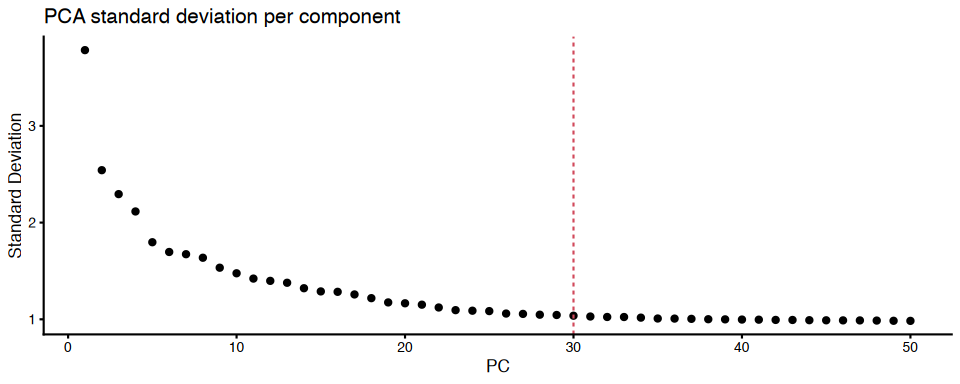

In [16]:
# Same recipe as Python Step 5: normalise to the median library size, log, scale, PCA
N_PCS <- 30
xen_qc <- NormalizeData(xen_qc, normalization.method = "LogNormalize",
                        scale.factor = median(xen_qc$nCount_Xenium), verbose = FALSE)
xen_qc <- ScaleData(xen_qc, features = rownames(xen_qc), verbose = FALSE)    # all 377 panel genes, no HVG step
xen_qc <- RunPCA(xen_qc, features = rownames(xen_qc), npcs = 50, verbose = FALSE)

options(repr.plot.width = 8, repr.plot.height = 3.2)
ElbowPlot(xen_qc, ndims = 50) + geom_vline(xintercept = N_PCS, colour = "#d1495b", linetype = "dashed") +
  ggtitle("PCA standard deviation per component") + theme_classic(base_size = 10)

### 5b. Neighbour graph, Leiden clustering at three resolutions, UMAP

Runtime ~3.5 min on ~154,000 cells (mostly UMAP).

In [17]:
RESOLUTIONS <- c(0.3, 0.5, 1.0)
t0 <- Sys.time()
xen_qc <- FindNeighbors(xen_qc, dims = 1:N_PCS, k.param = 15, verbose = FALSE)
xen_qc <- FindClusters(xen_qc, resolution = RESOLUTIONS, algorithm = 4, random.seed = 1, verbose = FALSE)  # 4 = Leiden
xen_qc <- suppressWarnings(RunUMAP(xen_qc, dims = 1:N_PCS, seed.use = 1, verbose = FALSE))   # R-native uwot
cat(sprintf("Neighbours + Leiden + UMAP: %.0f s\n", as.numeric(difftime(Sys.time(), t0, units = "secs"))))
data.frame(resolution = RESOLUTIONS,
           clusters = sapply(RESOLUTIONS, function(r) nlevels(xen_qc[[paste0("Xenium_snn_res.", r)]][, 1])))

Neighbours + Leiden + UMAP: 233 s


resolution,clusters
<dbl>,<int>
0.3,10
0.5,14
1.0,21


### 5c. Clusters on the UMAP and in the tissue

One panel per cluster shows where each sits in the tissue. Compare with the Python Step 5c: B-cell aggregates (TLS), smooth muscle tracing vessels and the pleura, ciliated cells lining an airway, and tumour programmes occupying separate regions.

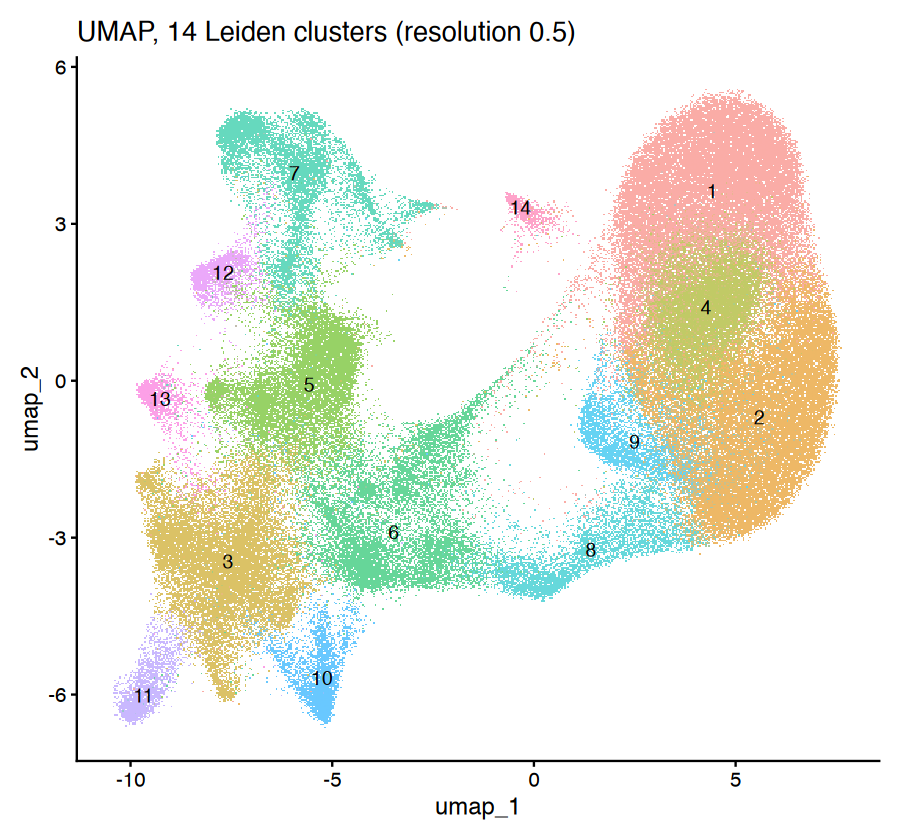

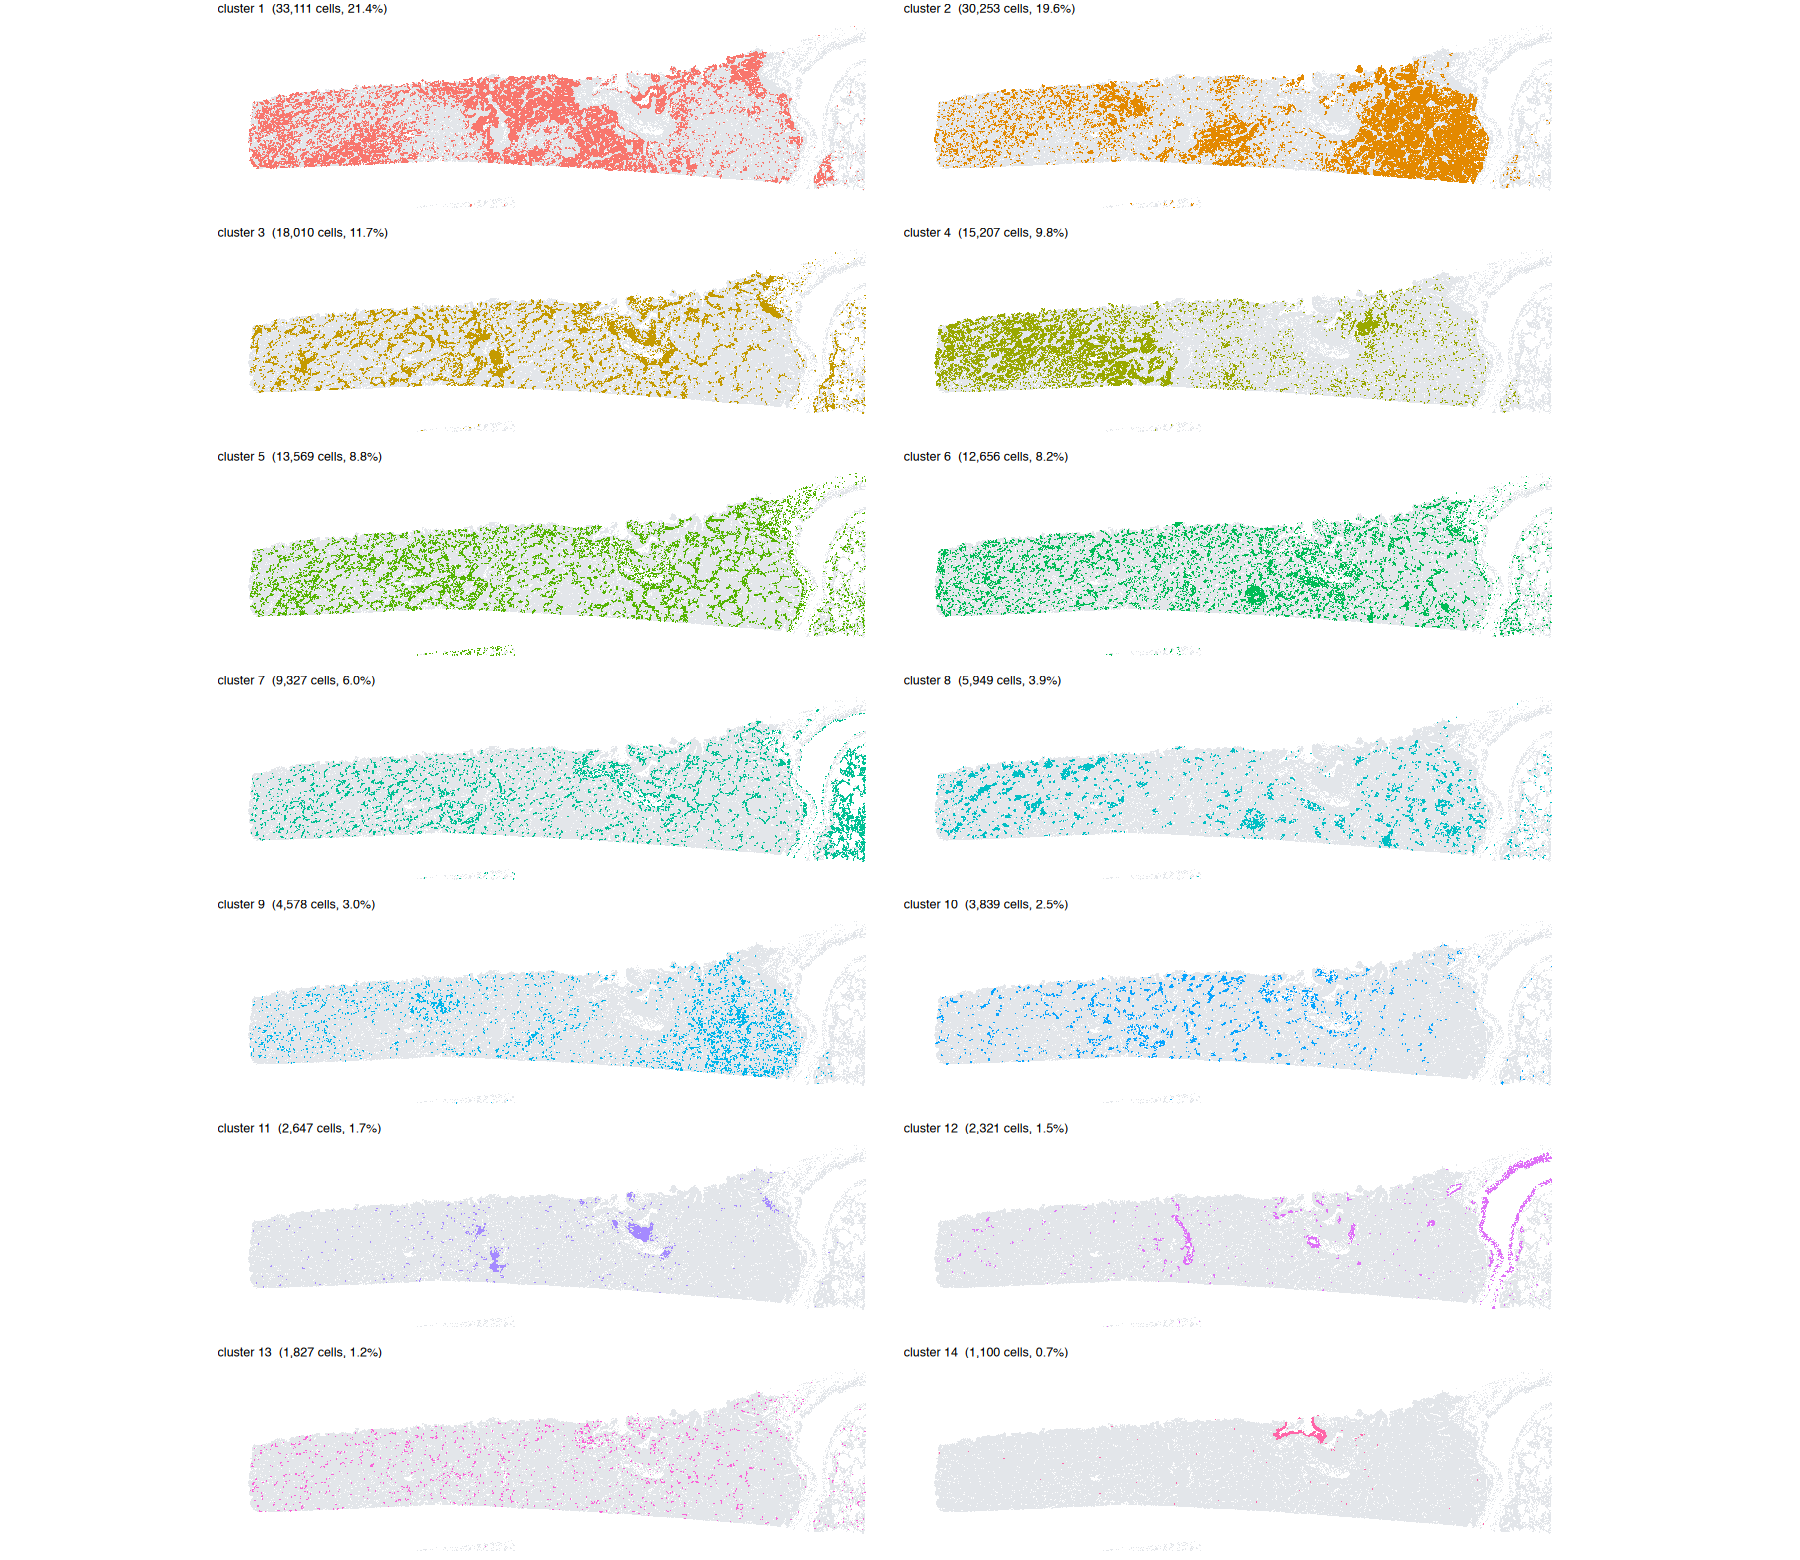

In [18]:
CLUSTER_KEY <- "Xenium_snn_res.0.5"
Idents(xen_qc) <- CLUSTER_KEY
options(repr.plot.width = 7.5, repr.plot.height = 7)
DimPlot(xen_qc, reduction = "umap", label = TRUE, label.size = 4, raster = TRUE, pt.size = 0.6) + NoLegend() +
  ggtitle(sprintf("UMAP, %d Leiden clusters (resolution 0.5)", nlevels(Idents(xen_qc))))

options(repr.plot.width = 15, repr.plot.height = 13)
cluster_panels(xen_qc, CLUSTER_KEY)

### 5d. Marker genes per cluster

With `presto` installed, Seurat's Wilcoxon test on ~154,000 cells takes seconds instead of minutes.

In [ ]:
# Marker genes: Wilcoxon test (Seurat uses presto automatically for speed)
t0 <- Sys.time()
markers <- FindAllMarkers(xen_qc, only.pos = TRUE, logfc.threshold = 1, min.pct = 0.1, verbose = FALSE)
cat(sprintf("FindAllMarkers: %.0f s\n", as.numeric(difftime(Sys.time(), t0, units = "secs"))))
top <- markers |> filter(p_val_adj < 0.01) |> group_by(cluster) |> slice_max(avg_log2FC, n = 6) |>
  summarise(cells = sum(Idents(xen_qc) == first(cluster)), top_markers = paste(gene, collapse = ", "))
top

options(repr.plot.width = 15, repr.plot.height = 5)
top3 <- markers |> filter(p_val_adj < 0.01) |> group_by(cluster) |> slice_max(avg_log2FC, n = 3) |> pull(gene) |> unique()
DotPlot(xen_qc, features = top3, cols = c("#e9ecef", "#1c5cab")) + RotatedAxis() +
  theme(axis.text.x = element_text(size = 8)) + ggtitle("Top 3 markers per cluster")

### 5e. Cross-check against Python and the 10x clustering

The Adjusted Rand Index (ARI) measures agreement between two partitions of the same cells (1 = identical, 0 = random). The Python cluster labels are read straight from its `.h5ad` file with `hdf5r` (anndata >= 0.12 stores strings as a group of `values` + `mask`, handled by the reader).

**Result:** R and Python agree strongly (**ARI ~0.72**), and each agrees equally with the 10x clustering (**~0.51**): two independent toolchains recover the same cell populations.

In [ ]:
# Cross-check against the Python (scanpy) clustering and the 10x clustering
read_h5ad_obs <- function(path, column) {      # read one categorical .obs column from an .h5ad file
  h <- H5File$new(path, mode = "r"); on.exit(h$close_all())
  read_strings <- function(node)   # anndata >= 0.12 stores strings as a group (values + mask)
    if (inherits(node, "H5Group")) node[["values"]]$read() else node$read()
  ids <- read_strings(h[["obs"]][["_index"]])
  g <- h[[paste0("obs/", column)]]
  setNames(as.character(read_strings(g[["categories"]])[g[["codes"]]$read() + 1]), ids)
}
py <- read_h5ad_obs(file.path(DATA_ROOT, "processed", paste0(SAMPLE, "_clustered.h5ad")), "leiden_0.5")
tmp <- tempfile(); untar(file.path(OUTS_DIR, "analysis.tar.gz"),
                         files = "analysis/clustering/gene_expression_graphclust/clusters.csv", exdir = tmp)
tenx <- read.csv(file.path(tmp, "analysis/clustering/gene_expression_graphclust/clusters.csv"))
tenx <- setNames(as.character(tenx$Cluster), tenx$Barcode)

shared <- intersect(colnames(xen_qc), names(py))
r_cl <- as.character(Idents(xen_qc)[shared])
data.frame(
  comparison = c("R (Seurat) vs Python (scanpy) Leiden 0.5", "R (Seurat) vs 10x graph clustering", "Python vs 10x (reference)"),
  ARI = round(c(mclust::adjustedRandIndex(r_cl, py[shared]), mclust::adjustedRandIndex(r_cl, tenx[shared]),
                mclust::adjustedRandIndex(py[shared], tenx[shared])), 3))
cat(sprintf("Same cells in both pipelines: %s\n", format(length(shared), big.mark = ",")))

saveRDS(xen_qc, file.path(R_DIR, paste0(SAMPLE, "_clustered_seurat.rds")))
cat("Saved:", show_path(file.path(R_DIR, paste0(SAMPLE, "_clustered_seurat.rds"))), "\n")